In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv(
    "../data/processed_logistics_data.csv",
    encoding="latin1"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 180519
Columns: 58


C:\Users\Jayita\AppData\Local\Temp\ipykernel_10268\4075849667.py:1: DtypeWarning: Columns (19: Customer Zipcode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [3]:
target = "Days for shipping (real)"

print(df[target].describe())

count    180519.000000
mean          3.497654
std           1.623722
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: Days for shipping (real), dtype: float64


In [4]:
features = [
    "Days for shipment (scheduled)",
    "Shipping Mode",
    "Order Region",
    "Market",
    "Order Item Quantity",
    "Order Item Product Price",
    "Order Item Discount",
    "Order Item Total",
    "Order Profit Per Order",
    "Customer Segment",
    "Order Status"
]

X = df[features].copy()
y = df[target].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (180519, 11)
Target shape: (180519,)


In [5]:
categorical_features = [
    "Shipping Mode",
    "Order Region",
    "Market",
    "Customer Segment",
    "Order Status"
]

numerical_features = [
    "Days for shipment (scheduled)",
    "Order Item Quantity",
    "Order Item Product Price",
    "Order Item Discount",
    "Order Item Total",
    "Order Profit Per Order"
]

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

Categorical features: 5
Numerical features: 6


In [6]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 144415
Testing rows: 36104


In [8]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [9]:
y_pred_linear = linear_model.predict(X_test)

In [10]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R²:", r2_linear)

Linear Regression
MAE: 0.98595148479938
RMSE: 1.266160488577933
R²: 0.39181819905629733


In [11]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                max_depth=10,
                random_state=42
            )
        )
    ]
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regressor")
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)
print("R²:", r2_tree)

Decision Tree Regressor
MAE: 0.9846675653437579
RMSE: 1.269692115098171
R²: 0.3884207364732427


In [12]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=15,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Regressor
MAE: 0.9850591356285607
RMSE: 1.2651263533975865
R²: 0.3928112569792883


In [13]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_tree,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_tree,
        rmse_rf
    ],
    "R2": [
        r2_linear,
        r2_tree,
        r2_rf
    ]
})

model_results = model_results.sort_values(
    "MAE",
    ascending=True
)

model_results

,Model,MAE,RMSE,R2
1,Decision Tree,0.984668,1.269692,0.388421
2,Random Forest,0.985059,1.265126,0.392811
0,Linear Regression,0.985951,1.266160,0.391818


In [14]:
model_results

,Model,MAE,RMSE,R2
1,Decision Tree,0.984668,1.269692,0.388421
2,Random Forest,0.985059,1.265126,0.392811
0,Linear Regression,0.985951,1.266160,0.391818


In [15]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_models = {
    "Linear Regression": linear_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

cv_results = []

for name, model in cv_models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV R2": scores.mean(),
        "Std CV R2": scores.std()
    })

cv_results = pd.DataFrame(cv_results)

cv_results

,Model,Mean CV R2,Std CV R2
0,Linear Regression,0.391694,0.004377
1,Decision Tree,0.387756,0.004296
2,Random Forest,0.392329,0.004598


In [20]:
from sklearn.model_selection import RandomizedSearchCV

fast_param_grid = {
    "model__n_estimators": [50, 75, 100],
    "model__max_depth": [10, 15],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

fast_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=fast_param_grid,
    n_iter=4,
    scoring="r2",
    cv=2,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [21]:
fast_search.fit(X_train, y_train)

print("Fast hyperparameter tuning completed!")

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Fast hyperparameter tuning completed!


In [22]:
print("Best Parameters:")
print(fast_search.best_params_)

print("\nBest CV R²:")
print(fast_search.best_score_)

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 10}

Best CV R²:
0.3914646163632966


In [23]:
best_model = fast_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest")
print("-------------------")
print("MAE:", mae_tuned)
print("RMSE:", rmse_tuned)
print("R²:", r2_tuned)

Tuned Random Forest
-------------------
MAE: 0.9825835040708054
RMSE: 1.2652973250098651
R²: 0.3926471325774017


In [24]:
comparison = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        mae_rf,
        mae_tuned
    ],
    "RMSE": [
        rmse_rf,
        rmse_tuned
    ],
    "R2": [
        r2_rf,
        r2_tuned
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Original Random Forest,0.985059,1.265126,0.392811
1,Tuned Random Forest,0.982584,1.265297,0.392647


In [25]:
print("Best Parameters:")
print(fast_search.best_params_)

print("\nBest CV R²:")
print(fast_search.best_score_)

print("\nFinal Tuned Random Forest Performance:")
print("MAE:", mae_tuned)
print("RMSE:", rmse_tuned)
print("R²:", r2_tuned)

print("\nModel Comparison:")
display(comparison)

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 10}

Best CV R²:
0.3914646163632966

Final Tuned Random Forest Performance:
MAE: 0.9825835040708054
RMSE: 1.2652973250098651
R²: 0.3926471325774017

Model Comparison:


,Model,MAE,RMSE,R2
0,Original Random Forest,0.985059,1.265126,0.392811
1,Tuned Random Forest,0.982584,1.265297,0.392647


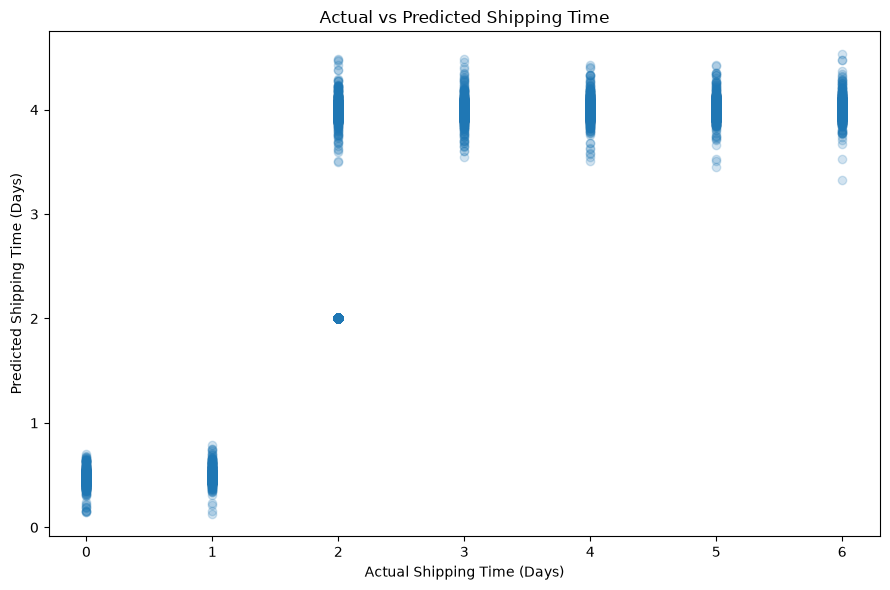

In [26]:
plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    y_pred_tuned,
    alpha=0.2
)

plt.xlabel("Actual Shipping Time (Days)")
plt.ylabel("Predicted Shipping Time (Days)")
plt.title("Actual vs Predicted Shipping Time")

plt.tight_layout()

plt.savefig(
    "../visualizations/actual_vs_predicted_shipping_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
import os

print(
    os.path.exists(
        "../visualizations/actual_vs_predicted_shipping_time.png"
    )
)

True


In [28]:
prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_tuned
})

prediction_results["Error"] = (
    prediction_results["Actual"]
    - prediction_results["Predicted"]
)

prediction_results["Absolute_Error"] = (
    prediction_results["Error"].abs()
)

prediction_results.head(10)

,Actual,Predicted,Error,Absolute_Error
0,5,3.984649,1.015351,1.015351
1,2,2.000000,0.000000,0.000000
2,2,3.972862,-1.972862,1.972862
3,5,3.998640,1.001360,1.001360
4,2,3.996429,-1.996429,1.996429
5,5,3.981829,1.018171,1.018171
6,6,3.978171,2.021829,2.021829
7,2,3.990396,-1.990396,1.990396
8,6,4.034814,1.965186,1.965186
9,4,3.986534,0.013466,0.013466


In [29]:
prediction_results["Absolute_Error"].describe()

count    36104.000000
mean         0.982584
std          0.797198
min          0.000000
25%          0.022952
50%          0.994540
75%          1.977694
max          2.675973
Name: Absolute_Error, dtype: float64

In [30]:
rf_final = best_model.named_steps["model"]

preprocessor_final = best_model.named_steps["preprocessor"]

In [31]:
feature_names = preprocessor_final.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_final.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,num__Days for shipment (scheduled),0.923718
7,cat__Shipping Mode_Same Day,0.029713
6,cat__Shipping Mode_First Class,0.021848
5,num__Order Profit Per Order,0.006830
4,num__Order Item Total,0.004312
3,num__Order Item Discount,0.003765
2,num__Order Item Product Price,0.001453
1,num__Order Item Quantity,0.000610
39,cat__Customer Segment_Corporate,0.000423
38,cat__Customer Segment_Consumer,0.000415


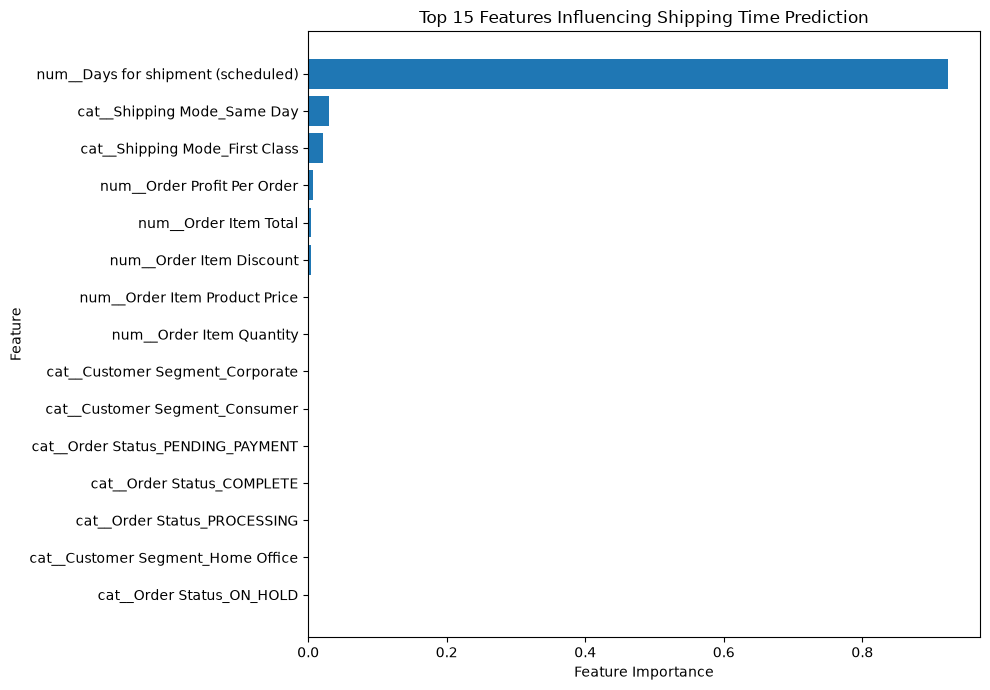

In [33]:
top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features Influencing Shipping Time Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../visualizations/top_15_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
# Create optimization dataset from the test set

test_results = X_test.copy()

test_results["Actual_Shipping_Days"] = y_test.values
test_results["Predicted_Shipping_Days"] = y_pred_tuned

test_results["Scheduled_Shipping_Days"] = (
    test_results["Days for shipment (scheduled)"]
)

test_results["Predicted_Schedule_Deviation"] = (
    test_results["Predicted_Shipping_Days"]
    - test_results["Scheduled_Shipping_Days"]
)

test_results["Predicted_Delay_Days"] = np.maximum(
    test_results["Predicted_Schedule_Deviation"],
    0
)

test_results["Predicted_Delay_Risk"] = (
    test_results["Predicted_Schedule_Deviation"] > 0
)

print("Optimization dataset created successfully.")
display(test_results.head())

Optimization dataset created successfully.


,Days for shipment (scheduled),Shipping Mode,Order Region,Market,Order Item Quantity,Order Item Product Price,Order Item Discount,Order Item Total,Order Profit Per Order,Customer Segment,Order Status,Actual_Shipping_Days,Predicted_Shipping_Days,Scheduled_Shipping_Days,Predicted_Schedule_Deviation,Predicted_Delay_Days,Predicted_Delay_Risk
80120,4,Standard Class,West of USA,USCA,1,199.990005,24.0,175.990005,11.090000,Consumer,PROCESSING,5,3.984649,4,-0.015351,0.0,False
19670,1,First Class,Central America,LATAM,5,50.000000,5.0,245.000000,9.800000,Consumer,PENDING_PAYMENT,2,2.000000,1,1.000000,1.0,True
114887,4,Standard Class,Central America,LATAM,5,49.980000,5.0,244.899994,117.550003,Corporate,PROCESSING,2,3.972862,4,-0.027138,0.0,False
120110,4,Standard Class,Southern Africa,Africa,1,299.980011,48.0,251.979996,118.430000,Consumer,PENDING,5,3.998640,4,-0.001360,0.0,False
56658,4,Standard Class,Caribbean,LATAM,3,39.990002,12.0,107.970001,-21.590000,Consumer,COMPLETE,2,3.996429,4,-0.003571,0.0,False


In [35]:
# Shipping-mode optimization summary

optimization_summary = (
    test_results.groupby("Shipping Mode")
    .agg(
        shipments=("Predicted_Shipping_Days", "count"),
        avg_predicted_shipping_days=("Predicted_Shipping_Days", "mean"),
        avg_scheduled_days=("Scheduled_Shipping_Days", "mean"),
        avg_predicted_delay_days=("Predicted_Delay_Days", "mean"),
        predicted_delay_rate=("Predicted_Delay_Risk", "mean")
    )
    .reset_index()
)

optimization_summary["predicted_delay_rate"] = (
    optimization_summary["predicted_delay_rate"] * 100
)

display(optimization_summary)

,Shipping Mode,shipments,avg_predicted_shipping_days,avg_scheduled_days,avg_predicted_delay_days,predicted_delay_rate
0,First Class,5531,2.000000,1.0,1.000000,100.00000
1,Same Day,1961,0.478150,0.0,0.478150,100.00000
2,Second Class,7026,3.996599,2.0,1.996599,100.00000
3,Standard Class,21586,3.994597,4.0,0.010271,36.43102


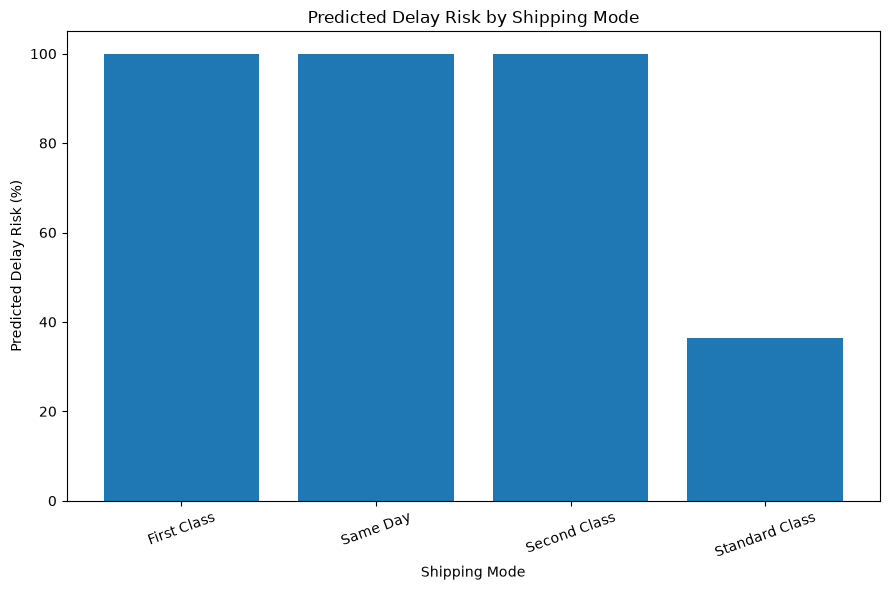

In [36]:
plt.figure(figsize=(9, 6))

plt.bar(
    optimization_summary["Shipping Mode"],
    optimization_summary["predicted_delay_rate"]
)

plt.title("Predicted Delay Risk by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Predicted Delay Risk (%)")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "../visualizations/predicted_delay_risk_by_shipping_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
# Regional optimization summary

regional_optimization = (
    test_results.groupby("Order Region")
    .agg(
        shipments=("Predicted_Shipping_Days", "count"),
        avg_predicted_shipping_days=("Predicted_Shipping_Days", "mean"),
        avg_scheduled_days=("Scheduled_Shipping_Days", "mean"),
        avg_predicted_delay_days=("Predicted_Delay_Days", "mean"),
        predicted_delay_rate=("Predicted_Delay_Risk", "mean")
    )
    .reset_index()
)

regional_optimization["predicted_delay_rate"] = (
    regional_optimization["predicted_delay_rate"] * 100
)

regional_optimization = regional_optimization.sort_values(
    "predicted_delay_rate",
    ascending=False
)

display(regional_optimization.head(10))

,Order Region,shipments,avg_predicted_shipping_days,avg_scheduled_days,avg_predicted_delay_days,predicted_delay_rate
4,Central Asia,108,3.340339,2.750000,0.595821,86.111111
2,Central Africa,360,3.574811,2.936111,0.649252,84.444444
6,East of USA,1385,3.490747,2.906137,0.591576,81.516245
19,West Africa,712,3.529679,2.984551,0.548700,77.808989
5,East Africa,374,3.501661,2.933155,0.572359,70.588235
22,Western Europe,5493,3.501946,2.909885,0.598700,70.198434
16,Southern Africa,213,3.317477,2.769953,0.557154,67.605634
9,North Africa,641,3.443152,2.886115,0.565904,63.650546
13,South Asia,1556,3.504734,2.902956,0.609062,62.339332
18,US Center,1202,3.499158,2.908486,0.598695,60.732113


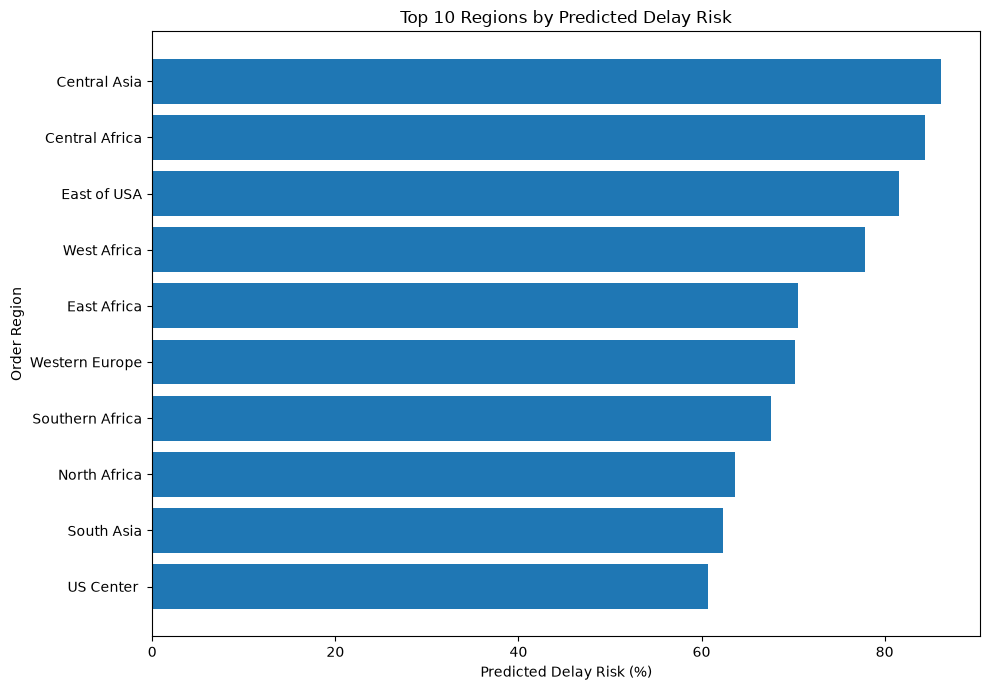

In [38]:
top_regions = (
    regional_optimization
    .head(10)
    .sort_values("predicted_delay_rate")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_regions["Order Region"],
    top_regions["predicted_delay_rate"]
)

plt.title("Top 10 Regions by Predicted Delay Risk")
plt.xlabel("Predicted Delay Risk (%)")
plt.ylabel("Order Region")

plt.tight_layout()

plt.savefig(
    "../visualizations/top_10_predicted_delay_regions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
overall_optimization = {
    "Total Test Shipments": len(test_results),
    "Predicted Delay Shipments": test_results["Predicted_Delay_Risk"].sum(),
    "Predicted Delay Rate (%)": (
        test_results["Predicted_Delay_Risk"].mean() * 100
    ),
    "Average Predicted Shipping Days": (
        test_results["Predicted_Shipping_Days"].mean()
    ),
    "Average Scheduled Shipping Days": (
        test_results["Scheduled_Shipping_Days"].mean()
    ),
    "Average Predicted Delay Days": (
        test_results["Predicted_Delay_Days"].mean()
    )
}

for key, value in overall_optimization.items():
    print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")

Total Test Shipments: 36104
Predicted Delay Shipments: 22382
Predicted Delay Rate (%): 61.9931
Average Predicted Shipping Days: 3.4984
Average Scheduled Shipping Days: 2.9339
Average Predicted Delay Days: 0.5739


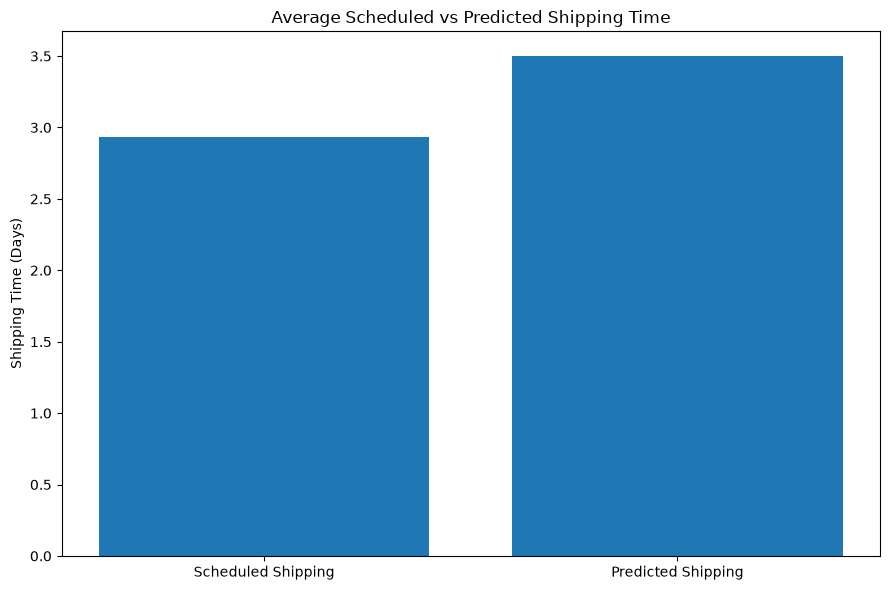

In [40]:
plt.figure(figsize=(9, 6))

plt.bar(
    ["Scheduled Shipping",
     "Predicted Shipping"],
    [
        test_results["Scheduled_Shipping_Days"].mean(),
        test_results["Predicted_Shipping_Days"].mean()
    ]
)

plt.title("Average Scheduled vs Predicted Shipping Time")
plt.ylabel("Shipping Time (Days)")
plt.tight_layout()

plt.savefig(
    "../visualizations/scheduled_vs_predicted_shipping_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()